# Corrosion Inhibitor Design (Langmuir + NORSOK + Nesic)

This notebook walks through inhibitor selection and dose optimization using
`neqsim.process.chemistry.corrosion.MechanisticCorrosionModel` and
`LangmuirInhibitorIsotherm`.

1. Compute bare-steel and inhibited corrosion rates for a wet gas export line.
2. Sweep dose -> efficiency curve at three temperatures.
3. Solve for the minimum dose required to meet a 0.1 mm/yr design target.
4. Compare two candidate inhibitor chemistries.

Standards: NORSOK M-506 (CO2 corrosion model), NACE SP0775 (corrosion
monitoring), Nesic 2007 (mass-transfer correlation).


In [1]:
import sys
from pathlib import Path

def find_project_root():
    p = Path.cwd().resolve()
    for cand in [p] + list(p.parents):
        if (cand / "pom.xml").exists() and (cand / "devtools" / "neqsim_dev_setup.py").exists():
            return cand
    raise RuntimeError("NeqSim project root not found")

ROOT = find_project_root()
sys.path.insert(0, str(ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_init(project_root=ROOT, recompile=False, verbose=False)
ns = neqsim_classes(ns)

import numpy as np
import matplotlib.pyplot as plt


All NeqSim classes imported OK


## 1. Base case — 6-inch wet-gas export line

In [2]:
Mech = ns.JClass("neqsim.process.chemistry.corrosion.MechanisticCorrosionModel")
Lang = ns.JClass("neqsim.process.chemistry.corrosion.LangmuirInhibitorIsotherm")

inhibitor = Lang()  # imidazoline defaults: K_ads=5000, dH=-35 kJ/mol, theta_max=0.95

m = (Mech()
    .setTemperatureCelsius(60.0)
    .setTotalPressureBara(80.0)
    .setGasComposition(0.05, 0.0)
    .setWaterChemistry(5.5, 250.0, 50000.0)
    .setFlow(2.0, 0.15, 1000.0, 1.0e-3)
    .setInhibitor(inhibitor, 50.0)
    .evaluate())

print(f"Re = {m.getReynoldsNumber():.2e}, Sh = {m.getSherwoodNumber():.0f}, Sc = {m.getSchmidtNumber():.0f}")
print(f"r_kin     = {m.getKineticRateMmYr():.2f} mm/yr")
print(f"r_mt      = {m.getMassTransferLimitedRateMmYr():.2f} mm/yr")
print(f"r_mixed   = {m.getMixedControlRateMmYr():.2f} mm/yr")
print(f"theta     = {m.getInhibitorCoverage():.2f}")
print(f"r_inhib   = {m.getInhibitedRateMmYr():.3f} mm/yr  (eta = {m.getInhibitorEfficiency():.0%})")


Re = 3.00e+05, Sh = 6273, Sc = 432
r_kin     = 0.91 mm/yr
r_mt      = 0.15 mm/yr
r_mixed   = 0.13 mm/yr
theta     = 0.14
r_inhib   = 0.114 mm/yr  (eta = 13%)


## 2. Dose -> efficiency curves at 40, 60, 80 C

Because the Langmuir adsorption is exothermic, efficiency drops with temperature.

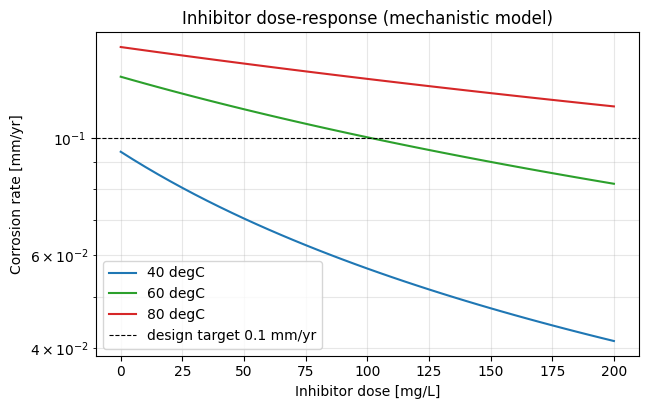

In [3]:
doses = np.linspace(0.0, 200.0, 41)
fig, ax = plt.subplots(figsize=(7, 4.2))
for T, color in zip([40.0, 60.0, 80.0], ["#1f77b4", "#2ca02c", "#d62728"]):
    rates = []
    for d in doses:
        mm = (Mech()
            .setTemperatureCelsius(T).setTotalPressureBara(80.0)
            .setGasComposition(0.05, 0.0)
            .setWaterChemistry(5.5, 250.0, 50000.0)
            .setFlow(2.0, 0.15, 1000.0, 1.0e-3)
            .setInhibitor(inhibitor, float(d))
            .evaluate())
        rates.append(mm.getInhibitedRateMmYr())
    ax.plot(doses, rates, "-", color=color, label=f"{T:.0f} degC")

ax.axhline(0.1, color="black", ls="--", lw=0.8, label="design target 0.1 mm/yr")
ax.set_xlabel("Inhibitor dose [mg/L]"); ax.set_ylabel("Corrosion rate [mm/yr]")
ax.set_title("Inhibitor dose-response (mechanistic model)")
ax.set_yscale("log"); ax.grid(True, which="both", alpha=0.3); ax.legend()
plt.show()


## 3. Minimum-dose optimisation

The Langmuir isotherm is analytically invertible. `getDoseForEfficiency` returns the dose required for a target *isotherm efficiency*, but the field-relevant target is a corrosion rate. Bracket-and-solve numerically:

In [4]:
def rate_at(T, dose):
    mm = (Mech()
        .setTemperatureCelsius(T).setTotalPressureBara(80.0)
        .setGasComposition(0.05, 0.0)
        .setWaterChemistry(5.5, 250.0, 50000.0)
        .setFlow(2.0, 0.15, 1000.0, 1.0e-3)
        .setInhibitor(inhibitor, float(dose))
        .evaluate())
    return mm.getInhibitedRateMmYr()

def min_dose(T, target_mmyr):
    lo, hi = 0.0, 500.0
    if rate_at(T, hi) > target_mmyr:
        return float("nan")  # target unreachable
    for _ in range(40):
        mid = 0.5 * (lo + hi)
        if rate_at(T, mid) > target_mmyr:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)

print(f"{'T [degC]':>10}  {'min dose for 0.1 mm/yr':>26}")
for T in [40.0, 60.0, 80.0, 100.0]:
    d = min_dose(T, 0.1)
    txt = f"{d:.1f} mg/L" if d == d else "unreachable"
    print(f"{T:>10.0f}  {txt:>26}")


  T [degC]      min dose for 0.1 mm/yr
        40                    0.0 mg/L
        60                  102.0 mg/L
        80                  334.4 mg/L
       100                 unreachable


## 4. Compare two candidate inhibitors

Swap the default imidazoline for a higher-performance quaternary-ammonium blend (higher K_ads, lower theta_max cap).

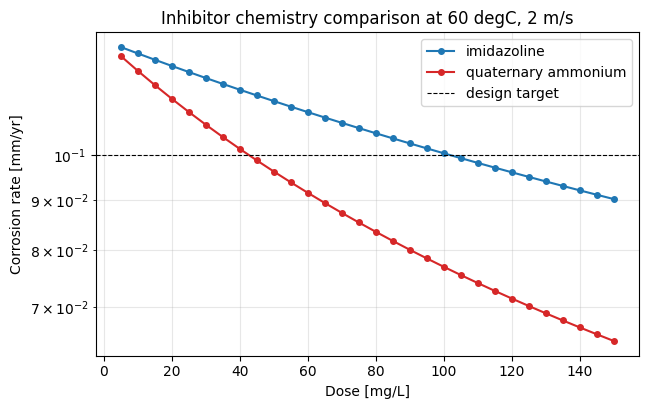

In [5]:
default   = Lang()                                    # imidazoline reference
quat_amm  = Lang(15000.0, -45.0, 0.93, 280.0)         # quaternary-ammonium

doses = np.linspace(5.0, 150.0, 30)
fig, ax = plt.subplots(figsize=(7, 4.2))
for inh, label, color in [(default, "imidazoline", "#1f77b4"),
                          (quat_amm, "quaternary ammonium", "#d62728")]:
    rates = []
    for d in doses:
        mm = (Mech()
            .setTemperatureCelsius(60.0).setTotalPressureBara(80.0)
            .setGasComposition(0.05, 0.0)
            .setWaterChemistry(5.5, 250.0, 50000.0)
            .setFlow(2.0, 0.15, 1000.0, 1.0e-3)
            .setInhibitor(inh, float(d))
            .evaluate())
        rates.append(mm.getInhibitedRateMmYr())
    ax.plot(doses, rates, "-o", color=color, label=label, ms=4)

ax.axhline(0.1, color="black", ls="--", lw=0.8, label="design target")
ax.set_xlabel("Dose [mg/L]"); ax.set_ylabel("Corrosion rate [mm/yr]")
ax.set_title("Inhibitor chemistry comparison at 60 degC, 2 m/s")
ax.set_yscale("log"); ax.grid(True, which="both", alpha=0.3); ax.legend()
plt.show()


## Summary

- The mechanistic model decomposes the rate into kinetic, mass-transfer-limited, and
  inhibited components — much more diagnostic than a single empirical "flow factor".
- Langmuir adsorption is exothermic, so high-temperature service requires either a
  higher dose, an inhibitor with a more negative `dHads`, or a chemistry with higher
  `K_ads_ref`.
- The bisection routine in section 3 is the same logic deployed in topside dosing
  controllers; pair it with [`MechanisticCorrosionModel`](../../docs/chemistry/mechanistic_corrosion.md)
  for online optimisation against measured wall-loss.

For the full theory and standards traceability, see
[`docs/chemistry/mechanistic_corrosion.md`](../../docs/chemistry/mechanistic_corrosion.md).
